Imperial MSc Statistics Thesis codes


Markov-switching Ornstein-Uhlenbeck process for modelling crude oil time spreads


28 August 2026


## Contents:
* [HMM-OU Model with Expectation Maximization](#first-bullet)
* [Backtest](#second-bullet)
* [Visualization plots](#third-bullet)
* [Fourth Bullet Header](#fourth-bullet)
* [Fifth Bullet Header](#fifth-bullet)
* [Sixth Bullet Header](#sixth-bullet)
* [Seventh Bullet Header](#seventh-bullet)
* [Eighth Bullet Header](#eighth-bullet)
* [Nineth Bullet Header](#nineth-bullet)
* [Tenth Bullet Header](#tenth-bullet)
* [Eleven Bullet Header](#eleven-bullet)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, gamma, invgamma
from scipy.optimize import minimize
from scipy.stats import (
    norm,
    skew,
    kurtosis,
    gaussian_kde
)
from scipy.stats import t as stud_t
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(12345678)

REGIME_NAMES = [
    "Contango",   
    "Normal Backwardation",  
    "Crisis" 
]

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

NU_DF = 5.0 

#Load data
df_raw = pd.read_csv("brent time spread_june.csv")
df_raw["Date"] = pd.to_datetime(df_raw["Date"],format="mixed",dayfirst=True)
df_raw.set_index("Date", inplace=True)
df_raw.sort_index(inplace=True)
# Optional date filter
# df_raw = df_raw.loc["2010-01-01":"2026-03-24"]
#resample to weekly
df_weekly = (df_raw.resample("W-FRI").last().dropna(subset=["spread"]))
df_weekly




## HMM-OU with Expectation Maximization <a class="anchor" id="first-bullet"></a>


fit_ou_weighted: weighted likelihood estimation with MAP, regime boundaries priors here. to use in M step part 1

fit_hmm_ou: EM loop to fit the 3 regime HMM-OU. Initialization of OU parameters and prior regime transition matrix

filter_update:

forward_filter: to use in E step



In [7]:
def fit_ou_weighted(x, dt, w, regime_idx=None):

    """
    Weighted OU Maximum A Posteriori (MAP) estimation.
    Economic boundaries and domain restrictions are enforced via L-BFGS-B limits
    and smooth Half-Normal Bayesian priors
    """
    x = np.asarray(x)
    x_t = x[:-1]
    x_tp1 = x[1:]
    w = np.asarray(w[:-1])
    w_sum = np.sum(w)
    overall_std = max(np.std(np.diff(x)), 1e-4)
    emp_std = max(np.std(x), 1e-4)

    contango_threshold = min(-0.01, np.percentile(x, 15)) 
    #crisis_threshold = np.percentile(x, 95)
    crisis_threshold = max(2.5, np.percentile(x, 95))

    def negative_log_posterior(params):
        kappa, mu, sigma = params
        #numerical safety fallbacks
        if kappa <= 0 or sigma <= 0: return 1e10

        # ========================================================
        # BASE LIKELIHOOD CALCULATION
        # ========================================================
        exp_k = np.exp(-kappa * dt)
        mean = mu + (x_t - mu) * exp_k
        var = (sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt))
        var = max(var, 1e-8)
        scale = np.sqrt(var * (NU_DF - 2) / NU_DF)
        ll = stud_t.logpdf(x_tp1, df=NU_DF, loc=mean, scale=scale)
        base_nll = -np.sum(w * ll)
        log_prior = 0.0

        # ========================================================
        # Piecewise Penalties to Half-Normal
        # ========================================================
        def half_normal_prior(val, boundary, scale_param, direction):
            """Applies a smooth Gaussian penalty ONLY when a boundary is crossed."""
            if (direction == "above" and val > boundary) or (direction == "below" and val < boundary):
                # Peak logpdf (at the boundary)
                peak = norm.logpdf(boundary, loc=boundary, scale=scale_param)
                # Current logpdf (further away from boundary)
                current = norm.logpdf(val, loc=boundary, scale=scale_param)
                # Returns a strictly NEGATIVE number that grows quadratically
                return current - peak
            return 0.0

        # Global Bound
        log_prior += half_normal_prior(abs(mu), 10.0, scale_param=0.002, direction="above")

        if regime_idx == 0:

            # dynamic anchor scaled to current market vol
            dynamic_anchor = contango_threshold - emp_std
            log_prior += norm.logpdf(mu, loc=dynamic_anchor, scale=emp_std*2.0)
            log_prior += invgamma.logpdf(sigma, a=3.0, scale=0.8)
            # boundaries : dynamically linked to contango_threshold, with capped vol
            log_prior += half_normal_prior(mu, contango_threshold, scale_param=0.05, direction="above")
            contango_vol_cap = max(emp_std * 1.5, 1.5)
            log_prior += half_normal_prior(sigma, contango_vol_cap, scale_param=0.1, direction="above")


        elif regime_idx == 1:
            log_prior += half_normal_prior(mu, 0.01, scale_param=0.007, direction="below")
            log_prior += half_normal_prior(mu, 3.0, scale_param=0.007, direction="above")
            log_prior += half_normal_prior(sigma, 6.0, scale_param=0.022, direction="above")
            

        elif regime_idx == 2:
            log_prior += half_normal_prior(mu, crisis_threshold, scale_param=0.007, direction="below")
            log_prior += half_normal_prior(mu, 1.0, scale_param=0.022, direction="below")

        return base_nll - log_prior 

    # ========================================================
    # solver bounds
    # ========================================================
    k_min, k_max = 1e-3, 50.0
    s_min, s_max = 1e-3, overall_std * 100.0

    if regime_idx == 0:
        mu_min, mu_max = -15.0, 0.0   
        mu_guess = min(-0.2, np.percentile(x, 10))
        init_sigma = 0.5
    elif regime_idx == 1: 
        mu_min, mu_max = 0.01, 3.0
        mu_guess = np.clip(np.median(x), contango_threshold + 0.1, crisis_threshold - 0.1)
        init_sigma = 1.5
    elif regime_idx == 2:
        mu_min, mu_max = max(1.0, crisis_threshold), 15.0                
        mu_guess = max(1.5, np.percentile(x, 95))
        init_sigma = 4.0
    else:
        mu_min, mu_max = -15.0, 15.0
        mu_guess = max(1.5, np.percentile(x, 95))
        init_sigma = 1.0

    mu_guess = np.clip(mu_guess, mu_min + 1e-4, mu_max - 1e-4)
    init = [1.0, mu_guess, init_sigma]

    res = minimize(negative_log_posterior, init, method="L-BFGS-B", 
        bounds=[(k_min, k_max), (mu_min, mu_max), (s_min, s_max)]
    )
    
    return res.x, res.fun


# EM LOOP

def fit_hmm_ou(x, dt, n_iter=5):
    """
    Fits a 3-state HMM-OU model using Expectation-Maximization.

    """
    x = np.asarray(x)
    K = 3
    T = len(x)
    overall_std = max(np.std(np.diff(x)), 1e-4)
    
    #data percentiles to dictate the start
    m0 = np.percentile(x, 10) 
    m1 = np.median(x)
    m2 = np.percentile(x, 90)

    params = [
        np.array([1.0, m0, overall_std * 0.7]), # 0: Contango
        np.array([1.0, m1, overall_std * 1.0]), # 1: Normal
        np.array([4.0, m2, overall_std * 3.0])  # 2: Crisis
    ]

    prior_P = np.array([
        [0.90, 0.10, 0.00], 
        [0.05, 0.90, 0.05], 
        [0.00, 0.30, 0.70]  
    ])
    
    P = prior_P.copy()
    ll_history = []
    param_history = []

    for iteration in range(n_iter):
        # ====================================================
        # E-STEP
        # ====================================================
        alpha, total_ll = forward_filter(x, params, P, dt)
        ll_history.append(total_ll)

        # ====================================================
        # M-STEP PART 1: PARAMETERS 
        # ====================================================
        new_params = []
        total_penalized_objective = 0.0


        for i in range(K):
            w = alpha[:, i]
            opt_params, opt_fun_val = fit_ou_weighted(x, dt, w, regime_idx=i)
            kappa, mu, sigma = opt_params
            
            new_params.append([kappa, mu, sigma])
            total_penalized_objective += -opt_fun_val


        params = np.array(new_params)
        param_history.append(params.copy())

        # ====================================================
        # M-STEP PART 2: TRANSITION MATRIX
        # ====================================================
        A_num = np.zeros((K, K))

        #Calculate Empirical Transitions
        for t in range(T - 1):
            obs_probs = np.zeros(K)
            for k in range(K):
                ki, mi, si = params[k]
                exp_k = np.exp(-ki * dt)
                mean = mi + (x[t] - mi) * exp_k
                var = max((si**2 / (2 * ki)) * (1 - np.exp(-2 * ki * dt)), 1e-8)
                scale = np.sqrt(var * (NU_DF - 2) / NU_DF)
                obs_probs[k] = stud_t.pdf(x[t + 1], df=NU_DF, loc=mean, scale=scale)

            joint = np.outer(alpha[t], obs_probs) * P
            if joint.sum() > 0:
                joint /= joint.sum()
            A_num += joint

        #Apply Bayesian inertia
        raw_P = np.zeros((K, K))
        inertia = 0.20
        for i in range(K):
            row_sum = A_num[i].sum()
            if row_sum > 1e-4:
                raw_P[i] = A_num[i] / row_sum
                P[i] = (raw_P[i] * (1.0 - inertia)) + (prior_P[i] * inertia)
            else:
                P[i] = prior_P[i].copy()

        #Clip & normalize
        P = np.clip(P, 1e-4, 1.0)
        row_sums = P.sum(axis=1, keepdims=True)
        P /= row_sums

        #sorting to prevent label switching in EM

        sorted_indices = np.argsort(params[:, 1]) # Sort by mu ascending
        params = params[sorted_indices]
        P = P[sorted_indices][:, sorted_indices]
        alpha = alpha[:, sorted_indices]

    return params, P, alpha, ll_history, np.array(param_history)


# FILTER UPDATE

def filter_update(alpha_prev, x_prev, x_curr, params, P, dt):
    K = len(params)
    pred = alpha_prev @ P
    obs = np.zeros(K)

    for k in range(K):
        kappa, mu, sigma = params[k]
        exp_k = np.exp(-kappa * dt)
        mean = mu + (x_prev - mu) * exp_k
        var = max((sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt)), 1e-8)
        scale = np.sqrt(var * (NU_DF - 2) / NU_DF)
        obs[k] = stud_t.pdf(x_curr, df=NU_DF, loc=mean, scale=scale)

    alpha_new = pred * obs
    s = np.sum(alpha_new)
    return alpha_new / s if s > 0 else np.ones(K) / K


# HMM-OU FILTER

def forward_filter(x, params, P, dt):
    T = len(x)
    K = len(params)
    alpha = np.zeros((T, K))
    alpha[0] = np.ones(K) / K
    log_lik_step = 0.0

    def emission_prob(x_prev, x_curr, kappa, mu, sigma):
        exp_k = np.exp(-kappa * dt)
        mean = mu + (x_prev - mu) * exp_k
        var = max((sigma**2 / (2 * kappa)) * (1 - np.exp(-2 * kappa * dt)), 1e-8)
        scale = np.sqrt(var * (NU_DF - 2) / NU_DF)
        return stud_t.pdf(x_curr, df=NU_DF, loc=mean, scale=scale)

    for t in range(T - 1):
        obs_probs = np.zeros(K)
        for i in range(K):
            kappa, mu, sigma = params[i]
            obs_probs[i] = emission_prob(x[t], x[t + 1], kappa, mu, sigma)

        pred = alpha[t] @ P
        raw = pred * obs_probs
        s = np.sum(raw)

        if s > 0:
            alpha[t + 1] = raw / s
            log_lik_step += np.log(s)
        else:
            alpha[t + 1] = np.ones(K) / K

    return alpha, log_lik_step

fit_single_ou

forecast_single_ou

forecast_hmm_ou: inertia, exponential smoothing, forecast based on mixture of regime means and var

In [8]:
# Single regime OU
def fit_single_ou(x, dt):
    x = np.asarray(x)
    w = np.ones(len(x))
    opt_params, _ = fit_ou_weighted(x, dt, w, regime_idx=None)
    kappa, mu, sigma = opt_params
    return np.array([kappa, mu, sigma])


# Single OU forecast
def forecast_single_ou(x_today,params,dt,h):
    kappa, mu, sigma = params
    mean = (mu + (x_today - mu) * np.exp(-kappa * h))
    nu = NU_DF
    var = (sigma**2/ (2 * kappa)* (1- np.exp(-2 * kappa * h)))

    #Student-t variance 
    var = (var* nu/ (nu - 2))
    std = np.sqrt(max(var,1e-8))

    return (mean,std)


# HMM-OU FORECAST 
def forecast_hmm_ou(x_today, params, alpha_t, P, dt, h, steps_ahead, prev_weights=None, inertia=0.8):
    K = len(params)

    #Raw projected probabilities
    P_n = np.linalg.matrix_power(P, steps_ahead)
    raw_weights = alpha_t @ P_n

    #apply exponential smoothing
    if prev_weights is not None:
        weights = (raw_weights * (1.0 - inertia)) + (prev_weights * inertia)
    else:
        weights = raw_weights


    """
    checking whether a state is active or has been dormant for a long time
    if a state's probability weight drops below a set activity threshold 
    (eg < 1% of the probability mass), exclude it so it doesn't drag the mixture forecast with boundary-pinned parameters
    """
    
    activity_threshold = 0.01
    weights = np.where(weights < activity_threshold, 0.0, weights)
    weights = np.where(weights < 0.02, 0.0, weights)
    
    weight_sum = np.sum(weights)
    if weight_sum > 1e-8:
        weights /= weight_sum
    else:
        weights = np.ones(K) / K

    #calculate means and vars based on the validated weights
    exp_k = np.array([np.exp(-p[0] * h) for p in params])
    means = np.array([p[1] + (x_today - p[1]) * exp_k[i] for i, p in enumerate(params)])
    
    nu = NU_DF
    vars_ = np.array([(p[2]**2 / (2 * p[0]) * (1 - np.exp(-2 * p[0] * h))) * nu / (nu - 2) for p in params])

    #final mixture blend using validated weights
    mix_mean = np.sum(weights * means)
    mix_var = np.sum(weights * (vars_ + means**2)) - mix_mean**2
    mix_var = max(mix_var, 1e-8)

    return mix_mean, np.sqrt(mix_var), weights



## Backtest<a class="anchor" id="second-bullet"></a>

In [9]:
def run_hmm_ou_backtest(
    df,
    col="spread",
    lookback=250,
    steps_ahead=1,
    freq="D",
    refit_every=20,
    verbose=True
):
    """
    Rolling HMM-OU backtest
    The model is refitted each window using only observations available before the forecast date
    """
    #data
    x = (df[col].dropna().values)
    dates = (df[col].dropna().index)
    periods_per_year = (252 if freq == "D" else 52)
    dt = (1/ periods_per_year)
    h = (steps_ahead/ periods_per_year)
    
    ema_array = pd.Series(x).ewm(span=4, adjust=False).mean().values

    results = []
    P_history = []
    param_history = []
    params = None
    P = None
    alpha = None
    single_ou_params = None
    single_ou_history = []
    #state tracker
    alpha_current = None

    # BACKTEST LOOP
    prev_weights = None
    for t in range(lookback,len(x) - steps_ahead):

        x_today = x[t]
        x_future = (x[t + steps_ahead])

        #adjustable refit frequency
        if (t == lookback or ((t - lookback)% refit_every== 0)):
            #train data
            train = x[t - lookback:t]
            (params,P,alpha,_, _) = fit_hmm_ou(train,dt)
            param_history.append(np.array(params).copy())
            # State probability at t-1
            alpha_current = (alpha[-1].copy())
            # Update state with x_today
            alpha_current = (filter_update(alpha_current, x[t - 1], x_today, params, P, dt))
            P_history.append(P.copy())
            single_ou_params = (fit_single_ou(train,dt))
            single_ou_history.append(np.array(single_ou_params).copy())

        else:
            # sequential filter update
            alpha_current = (filter_update(alpha_current,x[t - 1],x_today,params,P,dt))

        # HMM-OU FORECAST
        forecast_horizon = steps_ahead * dt

        (mix_mean, mix_std, smoothed_weights) = forecast_hmm_ou(x_today, params, alpha_current, P, dt, h=forecast_horizon, steps_ahead=steps_ahead, prev_weights = prev_weights, inertia=0.3)
        # Save today's smoothed weights for tomorrow's loop
        prev_weights = smoothed_weights

        #SINGLE OU FORECAST
        (single_ou_mean, single_ou_std) = forecast_single_ou(x_today, single_ou_params, dt, h)

        # ====================================================
        # DENSITY FORECASTING (LOG-PREDICTIVE SCORE)
        # ====================================================
        nu_df = NU_DF
        pdf_hmm = 0.0
        
        # Project Markov chain N steps forward
        P_n = np.linalg.matrix_power(P, steps_ahead)
        weights = alpha_current @ P

        for k in range(len(params)):
            k_i, m_i, sig_i = params[k]
            exp_k_i = np.exp(-k_i * forecast_horizon)
            mean_i = m_i + (x_today - m_i) * exp_k_i
            
            var_i = (sig_i**2 / (2 * k_i)) * (1 - np.exp(-2 * k_i * forecast_horizon))
            var_i = max(var_i, 1e-8)
            scale_i = np.sqrt(var_i * (nu_df - 2) / nu_df)
            
            # Apply the smoothed_weights directly
            pdf_hmm += smoothed_weights[k] * stud_t.pdf(x_future, df=nu_df, loc=mean_i, scale=scale_i)

        log_pred_hmm = np.log(max(pdf_hmm, 1e-10))

        # Single OU Density
        k_s, m_s, sig_s = single_ou_params
        exp_k_s = np.exp(-k_s * h)
        mean_s = m_s + (x_today - m_s) * exp_k_s
        
        var_s = (sig_s**2 / (2 * k_s)) * (1 - np.exp(-2 * k_s * h))
        var_s = max(var_s, 1e-8)
        scale_s = np.sqrt(var_s * (nu_df - 2) / nu_df)
        
        pdf_single = stud_t.pdf(x_future, df=nu_df, loc=mean_s, scale=scale_s)
        log_pred_single = np.log(max(pdf_single, 1e-10))

        # Benchmarks
        sma_4w = np.mean(x[t-4:t]) if t >= 4 else x_today
        ema_4w = ema_array[t]
        
        historical_drift = (x[t-1] - x[t-lookback]) / lookback
        drift_forecast = x_today + (historical_drift * steps_ahead)
        rw_forecast = x_today

        error = (x_future- mix_mean)
        
        # SAVE RESULTS
        m0, m1, m2 = params[0][1], params[1][1], params[2][1]
        blended_expected_mu = np.sum(alpha_current * params[:, 1])

        results.append({
            "date":dates[t + steps_ahead],
            "actual_today":x_today,
            "actual":x_future,
            "forecast":mix_mean,
            "std":mix_std,
            "error":error,
            "blended_mu": blended_expected_mu,      
            "mu_contango": m0,                     
            "mu_normal": m1,                        
            "mu_crisis": m2,
            "single_ou_forecast":single_ou_mean,
            "single_ou_std":single_ou_std,
            "single_ou_error":x_future- single_ou_mean,
            "rw_forecast": rw_forecast,
            "rw_error": x_future - rw_forecast,
            "lps_hmm": log_pred_hmm,
            "lps_single_ou": log_pred_single,
            "sma_forecast": sma_4w,
            "sma_error": x_future - sma_4w,
            "ema_forecast": ema_4w,
            "ema_error": x_future - ema_4w,
            "rw_drift_forecast": drift_forecast,
            "rw_drift_error": x_future - drift_forecast,
            "predicted_regime": np.argmax(alpha_current),
            **{(f"prob_"f"{REGIME_NAMES[i].replace(' ', '_').lower()}"):alpha_current[i]
                for i in range(len(REGIME_NAMES))}
        })

    res = pd.DataFrame(results)

    # forecast errors
    res["error"] = (res["actual"]- res["forecast"])
    res["abs_error"] = (np.abs(res["error"]))

    # WAPE
    total_abs_error = res["abs_error"].sum()
    total_abs_actual = np.sum(np.abs(res["actual"]))
    wape = (total_abs_error / max(total_abs_actual, 1e-8)) * 100.0

    # directional forecast
    res["predicted_move"] = (res["forecast"]- res["actual_today"])
    res["actual_move"] = (res["actual"]- res["actual_today"])
    res["predicted_direction"] = (np.sign(res["predicted_move"]))
    res["actual_direction"] = (np.sign(res["actual_move"]))
    res["direction_correct"] = (res["predicted_direction"]==res["actual_direction"])

    res["single_ou_move"] = res["single_ou_forecast"] - res["actual_today"]
    res["single_ou_direction_correct"] = np.sign(res["single_ou_move"]) == res["actual_direction"]

    # DENSITY-BASED TRADING SIGNAL (KELLY-STYLE SCALING)
    res["Edge"] = res["predicted_move"]
    res["Variance"] = res["std"] ** 2
    res["Target_Position"] = res["Edge"] / np.maximum(res["Variance"], 1e-4)

    max_leverage = 2.0
    res["Position_Size"] = np.clip(res["Target_Position"], -max_leverage, max_leverage)

    # PNL
    res["Binary_Signal"] = res["predicted_direction"]
    res["Binary_PnL"] = res["Binary_Signal"] * res["actual_move"]
    res["Binary_Cum_PnL"] = res["Binary_PnL"].cumsum()

    res["Strategy_PnL"] = res["Position_Size"] * res["actual_move"]
    res["Cumulative_PnL"] = res["Strategy_PnL"].cumsum()
    res["Drawdown"] = (res["Cumulative_PnL"].cummax()- res["Cumulative_PnL"])

    # Error Diagnostics
    res["inside"] = (np.abs(res["error"])< 2 * res["std"])
    res["standardized_error"] = (res["error"]/np.maximum(res["std"],1e-8))
    rmse = np.sqrt(np.mean(res["error"] ** 2))
    mae = np.mean(np.abs(res["error"]))
    bias = np.mean(res["error"])
    coverage_95 = np.mean(np.abs(res["error"])<1.96 * res["std"])

    z_crit_95 = 1.96 
    
    # Parametric model coverages using analytical standard deviations
    res["hmm_inside_95"] = np.abs(res["error"]) < (z_crit_95 * res["std"])
    res["single_ou_inside_95"] = np.abs(res["single_ou_error"]) < (z_crit_95 * res["single_ou_std"])

    # Non-parametric benchmark coverages using rolling error volatility scaling
    for bench in ["rw_error", "sma_error", "ema_error", "rw_drift_error"]:
        rolling_std = res[bench].rolling(window=20, min_periods=5).std().fillna(res[bench].std())
        res[bench.replace("_error", "_inside_95")] = np.abs(res[bench]) < (z_crit_95 * rolling_std)

    if verbose:
        # REGIME CONDITIONED PERFORMANCE
        print("\n===== REGIME-CONDITIONED PERFORMANCE =====")

        res["rw_error"] = (res["actual"] - res["actual_today"])
        res["hmm_ou_error"] = (res["actual"] - res["forecast"])
        res["single_ou_error"] = (res["actual"] - res["single_ou_forecast"])
        res["sma_error"] = (res["actual"] - res["sma_forecast"])
        res["ema_error"] = (res["actual"] - res["ema_forecast"])
        res["rw_drift_error"] = (res["actual"] - res["rw_drift_forecast"])

        regime_stats = (res.groupby("predicted_regime")
            .apply(
                lambda x: pd.Series({
                    "Days": len(x),
                    
                    # --- Raw RMSE ---
                    "HMM_OU_RMSE": np.sqrt(np.mean(x["hmm_ou_error"] ** 2)),
                    "Single_OU_RMSE": np.sqrt(np.mean(x["single_ou_error"] ** 2)),
                    "RW_RMSE": np.sqrt(np.mean(x["rw_error"] ** 2)),
                    "SMA_RMSE": np.sqrt(np.mean(x["sma_error"] ** 2)),
                    "EMA_RMSE": np.sqrt(np.mean(x["ema_error"] ** 2)),

                    # --- Regime-Wise 95% Coverage Rates (%) ---
                    "HMM_Cov_%": x["hmm_inside_95"].mean() * 100,
                    "Single_OU_Cov_%": x["single_ou_inside_95"].mean() * 100,
                    "RW_Cov_%": x["rw_inside_95"].mean() * 100,
                    "SMA_Cov_%": x["sma_inside_95"].mean() * 100,
                    "EMA_Cov_%": x["ema_inside_95"].mean() * 100,
                    "Drift_Cov_%": x["rw_drift_inside_95"].mean() * 100,
                    
                    # --- Raw MAE ---
                    "HMM_OU_MAE": np.mean(np.abs(x["hmm_ou_error"])),
                    "Single_OU_MAE": np.mean(np.abs(x["single_ou_error"])),
                    "RW_MAE": np.mean(np.abs(x["rw_error"])),
                    "SMA_MAE": np.mean(np.abs(x["sma_error"])),
                    "EMA_MAE": np.mean(np.abs(x["ema_error"])),

                    # --- RMSE Edge (% Improvement over Benchmarks) ---
                    "HMM_vs_SingleOU_RMSE_%": (1 - np.sqrt(np.mean(x["hmm_ou_error"] ** 2)) /
                                               max(np.sqrt(np.mean(x["single_ou_error"] ** 2)), 1e-8)) * 100,
                    "HMM_vs_RW_RMSE_%": (1 - np.sqrt(np.mean(x["hmm_ou_error"] ** 2)) / 
                                         max(np.sqrt(np.mean(x["rw_error"] ** 2)), 1e-8)) * 100,
                    "HMM_vs_SMA_RMSE_%": (1 - np.sqrt(np.mean(x["hmm_ou_error"] ** 2)) / 
                                          max(np.sqrt(np.mean(x["sma_error"] ** 2)), 1e-8)) * 100,
                    "HMM_vs_EMA_RMSE_%": (1 - np.sqrt(np.mean(x["hmm_ou_error"] ** 2)) / 
                                          max(np.sqrt(np.mean(x["ema_error"] ** 2)), 1e-8)) * 100,

                    # --- MAE Edge (% Improvement over Benchmarks) ---
                    "HMM_vs_SingleOU_MAE_%": (1 - np.mean(np.abs(x["hmm_ou_error"])) / 
                                              max(np.mean(np.abs(x["single_ou_error"])), 1e-8)) * 100,
                    "HMM_vs_RW_MAE_%": (1 - np.mean(np.abs(x["hmm_ou_error"])) / 
                                        max(np.mean(np.abs(x["rw_error"])), 1e-8)) * 100,
                    "HMM_vs_SMA_MAE_%": (1 - np.mean(np.abs(x["hmm_ou_error"])) / 
                                         max(np.mean(np.abs(x["sma_error"])), 1e-8)) * 100,
                    "HMM_vs_EMA_MAE_%": (1 - np.mean(np.abs(x["hmm_ou_error"])) / 
                                         max(np.mean(np.abs(x["ema_error"])), 1e-8)) * 100,

                    "PnL": x["Strategy_PnL"].sum(),
                    "Hit_Rate_%": x["direction_correct"].mean() * 100
                })
            )
        )

        regime_stats.index = [
            REGIME_NAMES[i] if isinstance(i, int) and i < len(REGIME_NAMES) else i
            for i in regime_stats.index]

        all_periods = pd.Series({
            "Days": len(res),
            
            # --- Raw RMSE ---
            "HMM_OU_RMSE": np.sqrt(np.mean(res["hmm_ou_error"] ** 2)),
            "Single_OU_RMSE": np.sqrt(np.mean(res["single_ou_error"] ** 2)),
            "RW_RMSE": np.sqrt(np.mean(res["rw_error"] ** 2)),
            "SMA_RMSE": np.sqrt(np.mean(res["sma_error"] ** 2)),
            "EMA_RMSE": np.sqrt(np.mean(res["ema_error"] ** 2)),

            # --- Overall 95% Coverages ---
            "HMM_Cov_%": res["hmm_inside_95"].mean() * 100,
            "Single_OU_Cov_%": res["single_ou_inside_95"].mean() * 100,
            "RW_Cov_%": res["rw_inside_95"].mean() * 100,
            "SMA_Cov_%": res["sma_inside_95"].mean() * 100,
            "EMA_Cov_%": res["ema_inside_95"].mean() * 100,
            "Drift_Cov_%": res["rw_drift_inside_95"].mean() * 100,
            
            # --- Raw MAE ---
            "HMM_OU_MAE": np.mean(np.abs(res["hmm_ou_error"])),
            "Single_OU_MAE": np.mean(np.abs(res["single_ou_error"])),
            "RW_MAE": np.mean(np.abs(res["rw_error"])),
            "SMA_MAE": np.mean(np.abs(res["sma_error"])),
            "EMA_MAE": np.mean(np.abs(res["ema_error"])),

            # --- RMSE Edge ---
            "HMM_vs_SingleOU_RMSE_%": (1 - np.sqrt(np.mean(res["hmm_ou_error"] ** 2)) /
                                       max(np.sqrt(np.mean(res["single_ou_error"] ** 2)), 1e-8)) * 100,
            "HMM_vs_RW_RMSE_%": (1 - np.sqrt(np.mean(res["hmm_ou_error"] ** 2)) /
                                 max(np.sqrt(np.mean(res["rw_error"] ** 2)), 1e-8)) * 100,
            "HMM_vs_SMA_RMSE_%": (1 - np.sqrt(np.mean(res["hmm_ou_error"] ** 2)) / 
                                  max(np.sqrt(np.mean(res["sma_error"] ** 2)), 1e-8)) * 100,
            "HMM_vs_EMA_RMSE_%": (1 - np.sqrt(np.mean(res["hmm_ou_error"] ** 2)) / 
                                  max(np.sqrt(np.mean(res["ema_error"] ** 2)), 1e-8)) * 100,

            # --- MAE Edge ---
            "HMM_vs_SingleOU_MAE_%": (1 - np.mean(np.abs(res["hmm_ou_error"])) / 
                                      max(np.mean(np.abs(res["single_ou_error"])), 1e-8)) * 100,
            "HMM_vs_RW_MAE_%": (1 - np.mean(np.abs(res["hmm_ou_error"])) / 
                                max(np.mean(np.abs(res["rw_error"])), 1e-8)) * 100,
            "HMM_vs_SMA_MAE_%": (1 - np.mean(np.abs(res["hmm_ou_error"])) / 
                                 max(np.mean(np.abs(res["sma_error"])), 1e-8)) * 100,
            "HMM_vs_EMA_MAE_%": (1 - np.mean(np.abs(res["hmm_ou_error"])) / 
                                 max(np.mean(np.abs(res["ema_error"])), 1e-8)) * 100,

            "PnL": res["Strategy_PnL"].sum(),
            "Hit_Rate_%": res["direction_correct"].mean() * 100
        }, name="All Periods")

        regime_stats = pd.concat([regime_stats, all_periods.to_frame().T])

        print("\n===== REGIME PERFORMANCE COMPARISON =====")
        print(regime_stats.round(4).to_string())

    return (res, param_history, P_history, single_ou_history)

In [12]:
#RUN BACKTEST

lookback = 104
res_df, param_history, P_history, single_ou_history = (
    run_hmm_ou_backtest(
        df_weekly,
        col="spread",
        lookback=lookback,
        steps_ahead=3,
        freq="W",
        refit_every=1,
        verbose=True))

# 2. Extract the final training data window used in the last refit
x = df_weekly["spread"].dropna().values
final_train_data = x[-lookback:] # using lookback window size

# 3. Extract the latest single OU parameters and transition matrix P
latest_single_ou_params = single_ou_history[-1]
latest_P = P_history[-1]

#FINAL MODEL
dt = 1 / 52
last_window = (df_weekly["spread"].dropna().values[-lookback:])

# Fit final model
(final_params,final_P,final_alpha,final_ll,final_param_history) = fit_hmm_ou(last_window,dt)


===== REGIME-CONDITIONED PERFORMANCE =====

===== REGIME PERFORMANCE COMPARISON =====
                       Days  HMM_OU_RMSE  Single_OU_RMSE  RW_RMSE  SMA_RMSE  EMA_RMSE  HMM_Cov_%  Single_OU_Cov_%  RW_Cov_%  SMA_Cov_%  EMA_Cov_%  Drift_Cov_%  HMM_OU_MAE  Single_OU_MAE  RW_MAE  SMA_MAE  EMA_MAE  HMM_vs_SingleOU_RMSE_%  HMM_vs_RW_RMSE_%  HMM_vs_SMA_RMSE_%  HMM_vs_EMA_RMSE_%  HMM_vs_SingleOU_MAE_%  HMM_vs_RW_MAE_%  HMM_vs_SMA_MAE_%  HMM_vs_EMA_MAE_%      PnL  Hit_Rate_%
Contango              139.0       0.4143          0.4161   0.4160    0.4728    0.4335    98.5612          98.5612   92.0863    92.0863    88.4892      92.0863      0.2751         0.2720  0.2836   0.3176   0.2890                  0.4455            0.4050            12.3735             4.4233                -1.1667           2.9852           13.3592            4.8067   1.5193     64.7482
Normal Backwardation  539.0       0.7830          0.7946   0.7909    0.8755    0.8004    96.6605          94.6197   92.0223    91.8367 

/var/folders/x_/xgs_88f130lgzk9fvyd6tf5c0000gn/T/ipykernel_2461/3767574412.py:216: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  regime_stats = (res.groupby("predicted_regime")


## Visualization plots<a class="anchor" id="third-bullet"></a>


plot_regime_probabilities: raw time series + forecast + predicted regime probabilities 

plot_results: forecast error

plot_ou_parameter_3d

plot_parameter_history_grid

plot_parameter_pairplot

plot_transition_matrix_heatmap

plot_density_edge: cumulative log predictive score

plot_hmm_empirical_diagnostics

plot_estimated_ou_mean

def plot_rolling_durations_smoothed

In [33]:
def plot_regime_probabilities(res):
    """
    Plot actual spread, forecast and regime probabilities.
    """
    fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14, 8),sharex=True,gridspec_kw={"height_ratios": [1, 1]})

    #top panel
    ax1.plot(res["date"],res["actual"],label="Actual Spread",color="black",alpha=0.8)
    ax1.plot(res["date"],res["forecast"],label="1-Step Forecast",color="crimson",linestyle="--")
    ax1.fill_between(res["date"],res["forecast"] - 2 * res["std"],res["forecast"]+ 2 * res["std"],color="crimson",alpha=0.1,label="95% CI")
    ax1.set_title("Brent Time Spread & ""HMM-OU Regime Probabilities",fontsize=14,fontweight="bold")
    ax1.set_ylabel("Spread Value")
    ax1.legend(loc="upper left")
    ax1.grid(True,alpha=0.3)

    #bottom panel
    prob_cols = [(f"prob_"f"{name.replace(' ', '_').lower()}")for name in REGIME_NAMES]
    ax2.stackplot(res["date"],*[res[col]for col in prob_cols],labels=REGIME_NAMES,colors=[ "#2ca02c", "#ff7f0e","#d62728"],alpha=0.85)
    ax2.set_ylabel("Probability")
    ax2.set_xlabel("Date")
    ax2.set_ylim(0,1)
    ax2.legend(loc="lower left",framealpha=0.9)
    ax2.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.savefig("hmm_ou_chart.pdf",format="pdf",bbox_inches="tight")
    plt.show()

def plot_results(res):

    plt.figure(figsize=(12, 5))
    plt.plot(res["date"],res["actual"],label="Actual")
    plt.plot(res["date"],res["forecast"],label="Forecast")
    plt.fill_between( res["date"],res["forecast"]- 2 * res["std"],res["forecast"]+ 2 * res["std"],alpha=0.3)

    plt.legend()
    plt.title("3-State HMM-OU Forecast")
    plt.grid()
    plt.show()
    # --------------------------------------------------------
    # Forecast error
    # --------------------------------------------------------
    plt.figure(figsize=(12, 4))
    plt.plot(res["date"],res["error"])
    plt.axhline(0,color="black")
    plt.title("Forecast Error")
    plt.grid()
    plt.savefig("forecast error.pdf",format="pdf",bbox_inches="tight")
    plt.show()

def plot_ou_parameter_3d(param_history):

    param_history = np.asarray(param_history)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    colors = ["green", "orange", "red"]

    for r in range(param_history.shape[1]):
        ax.scatter(
            param_history[:, r, 0],
            param_history[:, r, 1],
            param_history[:, r, 2],
            s=35,
            alpha=0.7,
            color=colors[r],
            label=REGIME_NAMES[r]
        )

    ax.set_xlabel("κ (mean reversion)")
    ax.set_ylabel("μ (long-run mean)")
    ax.set_zlabel("σ (volatility)")
    ax.set_title("OU Parameters by HMM Regime")
    ax.legend(loc="upper left",bbox_to_anchor=(0.82, 0.95),fontsize=10)
    plt.tight_layout()
    plt.show()
    n_refits = param_history.shape[0]
    n_regimes = param_history.shape[1]
    print(f"Refits: {n_refits}")
    print(f"Regimes: {n_regimes}")
    print(f"Total points: {n_refits * n_regimes}")

def plot_parameter_history_grid(param_history):
    """
    Plot OU parameter evolution across rolling refits.
    """
    param_history = np.asarray(param_history)
    n_refits = (param_history.shape[0])
    regime_names = REGIME_NAMES

    parameter_names = [
        r"$\kappa$ (Mean Reversion)",
        r"$\mu$ (Long-run Mean)",
        r"$\sigma$ (Volatility)"]

    colors = ["forestgreen","darkorange","firebrick"]
    fig, axes = plt.subplots(3,3,figsize=(15, 10),sharex=True)
    x = np.arange(n_refits)
    for regime in range(3):

        for p in range(3):
            ax = axes[regime,p]
            y = (param_history[:,regime,p])
            ax.plot(x,y,color=colors[regime],lw=2)
            ax.scatter(x,y,color=colors[regime],s=18)
            ax.axhline(np.mean(y),color="black",linestyle="--",alpha=0.5,linewidth=1)
            ax.grid(alpha=0.3)
            if regime == 0:
                ax.set_title(parameter_names[p],fontsize=11)
            if p == 0: ax.set_ylabel(regime_names[regime],fontsize=11)
            if regime == 2: ax.set_xlabel("Rolling Refit Number")

    plt.suptitle(
        "OU Parameter Stability Across Rolling Refits", fontsize=15,fontweight="bold")
    plt.tight_layout()
    plt.show()

def plot_parameter_pairplot(param_history):

    param_history = np.asarray(param_history)
    regime_names = REGIME_NAMES
    colors = ["forestgreen","darkorange","firebrick"]
    param_labels = [r"$\kappa$",r"$\mu$",r"$\sigma$"]
    fig, axes = plt.subplots(3,3, figsize=(12, 12))

    for i in range(3):
        for j in range(3):
            ax = axes[i,j]
            if i == j:
                #histogram
                for r in range(3):
                    values = (param_history[:,r,i])
                    ax.hist(values,bins=12,alpha=0.45,color=colors[r],density=True,
                        label=(regime_names[r] if i == 0 else None))
            else:
                #scatter
                for r in range(3):
                    ax.scatter(
                        param_history[:,r,j],
                        param_history[:,r,i],
                        color=colors[r],alpha=0.75,s=35)

            if i == 2: ax.set_xlabel(param_labels[j])
            if j == 0: ax.set_ylabel(param_labels[i])

            ax.grid(alpha=0.25)

    handles, labels = (axes[0, 0].get_legend_handles_labels())
    fig.legend(handles,labels,loc="upper center",ncol=3)
    plt.suptitle("OU Parameter Pair Plot",fontsize=15,fontweight="bold")
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.show()

def plot_transition_matrix_heatmap(P_history,average=True):
    """
    HMM transition probabilities heatmap
    average=True for Average transition matrix.
    average=False for Final transition matrix.
    """
    P_history = np.asarray(P_history)

    if len(P_history) == 0:
        print("P_history is empty.")
        return
    if average:
        P = (P_history.mean(axis=0))
        title = ("Average Transition Matrix")
    else:
        P = P_history[-1]
        title = ("Final Transition Matrix")

    regime_names = REGIME_NAMES
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(P,cmap="Blues",vmin=0,vmax=1)
    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(regime_names)
    ax.set_yticklabels(regime_names)
    ax.set_xlabel("Next Regime")
    ax.set_ylabel("Current Regime")
    ax.set_title(title)

    for i in range(3):
        for j in range(3):
            ax.text(j,i,f"{P[i, j]:.2f}",
                ha="center",va="center",
                color=("white"if P[i, j] > 0.5 else "black"),fontsize=11,fontweight="bold")

    plt.colorbar(im,ax=ax,label="Transition Probability")
    plt.tight_layout()
    plt.savefig("avgmatrix.pdf",format="pdf",bbox_inches="tight")
    plt.show()

def plot_density_edge(res_df):
    """
    Plots the Cumulative Log-Predictive Score out-of-sample
    """
    res_df["clps_hmm"] = res_df["lps_hmm"].cumsum()
    res_df["clps_single"] = res_df["lps_single_ou"].cumsum()
    
    # Calculate the widening gap (the edge)
    res_df["hmm_edge"] = res_df["clps_hmm"] - res_df["clps_single"]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    
    # Top Panel: Cumulative Scores
    ax1.plot(res_df["date"], res_df["clps_hmm"], label="HMM-OU (Mixture Density)", color="forestgreen", lw=2)
    ax1.plot(res_df["date"], res_df["clps_single"], label="Single OU (Static Density)", color="firebrick", lw=2)
    ax1.set_title("Out-of-Sample Density Forecasting Performance (CLPS)", fontsize=14, fontweight="bold")
    ax1.set_ylabel("Cumulative Log-Likelihood")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)
    
    # Bottom Panel: The HMM Edge
    ax2.fill_between(res_df["date"], 0, res_df["hmm_edge"], color="steelblue", alpha=0.3)
    ax2.plot(res_df["date"], res_df["hmm_edge"], color="steelblue", lw=1.5, label="HMM Cumulative Outperformance")
    ax2.set_ylabel("Edge (LL Difference)")
    ax2.legend(loc="upper left")
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    total_hmm_ll = res_df["lps_hmm"].sum()
    total_single_ll = res_df["lps_single_ou"].sum()
    
    print("\n===== OUT-OF-SAMPLE DENSITY SCORES =====")
    print(f"HMM-OU Total Log-Likelihood   : {total_hmm_ll:.2f}")
    print(f"Single OU Total Log-Likelihood: {total_single_ll:.2f}")
    print(f"Total HMM Edge (Information)  : {total_hmm_ll - total_single_ll:+.2f}")

def plot_hmm_empirical_diagnostics(res_df,df_weekly,LOOKBACK,params):

    params = np.array(params)
    train_data = (df_weekly["spread"].dropna().values[-LOOKBACK:])
    alpha_cols = [(f"prob_" f"{name.replace(' ', '_').lower()}") for name in REGIME_NAMES]
    alpha_t = (res_df[alpha_cols].iloc[-1].values)
    n_sims = 5000
    regime_sims = []

    # SIMULATE EACH REGIME
    for i in range(3):
        k, m, sig = params[i]
        dt = 1 / 52
        exp_k = np.exp( -k * dt)
        step_var = (sig**2 / (2 * k)* (1 - np.exp(-2 * k * dt)))
        n_regime_sims = max(1,int(alpha_t[i]* n_sims))
        nu = NU_DF
        scale = np.sqrt(step_var* (nu - 2) / nu)
        shock = stud_t.rvs(df=nu,scale=scale,size=n_regime_sims)
        sims = (m+ (train_data[-1]- m)* exp_k+ shock)
        regime_sims.append(sims)

    plt.figure(figsize=(12, 7))
    colors = ["#2ca02c", "#ff7f0e", "#d62728"]
    labels = REGIME_NAMES
    plt.hist(regime_sims,bins=50,density=True,histtype="barstacked",color=colors,alpha=0.5,label=labels)

    #historical KDE
    try:
        kde = gaussian_kde(train_data)
        all_sims = np.concatenate(regime_sims)
        lower = min(train_data.min(),all_sims.min()) - 1
        upper = max(train_data.max(),all_sims.max()) + 1
        x_range = np.linspace(lower,upper,200)

        plt.plot(x_range,kde(x_range),color="purple",lw=3,label="80-Week History (KDE)")

    except Exception:
        pass

    #current price
    plt.axvline(train_data[-1],color="red",linestyle="--",label="Current Price")

    plt.axvline(np.mean(np.concatenate(regime_sims)),color="green",linestyle="-",linewidth=2,label="HMM Forecast Mean")

    plt.title(
        "Empirical Distribution: "
        "HMM-OU Regime-Separated "
        "Forecast vs. Market History")

    plt.xlabel("Spread ($/bbl)")
    plt.yticks([])
    plt.legend()
    plt.grid(True,alpha=0.3)
    plt.show()

def plot_estimated_ou_mean(res_df):
    """
    Plots the raw time series alongside the HMM-OU model's estimated 
    rolling blended equilibrium mean (mu) and individual state means.
    """
    plt.figure(figsize=(14, 6))
    # 1. Raw data
    plt.plot(res_df["date"], res_df["actual"], label="Actual Spread (Future)", color="black", alpha=0.3, lw=1)
    # 2. Blended expected OU mean
    if "blended_mu" in res_df.columns:
        plt.plot(res_df["date"], res_df["blended_mu"], label="Blended Expected OU Equilibrium ($\sum P_k \mu_k$)", color="crimson", lw=2)
    
    # 3. Individual regime means
    if "mu_normal" in res_df.columns:
        plt.plot(res_df["date"], res_df["mu_normal"], label="Normal Backwardation Mean ($\mu_1$)", color="orange", linestyle="--", alpha=0.7, lw=1.5)
    if "mu_contango" in res_df.columns:
        plt.plot(res_df["date"], res_df["mu_contango"], label="Contango Mean ($\mu_0$)", color="forestgreen", linestyle="--", alpha=0.7, lw=1.5)
    if "mu_crisis" in res_df.columns:
        plt.plot(res_df["date"], res_df["mu_crisis"], label="Crisis Mean ($\mu_2$)", color="firebrick", linestyle="--", alpha=0.7, lw=1.5)

    plt.title("OU Framework Verification: Raw Spread vs. Estimated Rolling OU Equilibrium ($\mu$)", fontsize=14, fontweight="bold")
    plt.xlabel("Date")
    plt.ylabel("Spread Value ($/bbl)")
    plt.axhline(0, color="gray", linestyle=":", alpha=0.7)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("estimated_ou_mean.pdf", format="pdf", bbox_inches="tight")
    plt.show()

def plot_density_and_likelihood5(params,ll_history,full_data,regime_names=REGIME_NAMES):
    """
    Plots:

    Panel 1:
        Theoretical steady-state densities for the 3 HMM regimes against the FULL historical dataset.
    Panel 2:
        EM log-likelihood convergence.
    IMPORTANT:
        The HMM parameters are those supplied in `params`, but the
        empirical histogram and x-axis range use the FULL history.
    """
    params = np.asarray(params, dtype=float)
    full_data = np.asarray(full_data, dtype=float)
    if len(params) != 3:raise ValueError(f"Expected 3 regimes, got {len(params)}")
    colors = ["#2ca02c","#ff7f0e","#d62728"]

    try:
        nu = NU_DF
    except NameError:
        nu = 5.0

    fig, (ax1, ax2) = plt.subplots(1,2,figsize=(17, 6))
    # ==========================================================
    # PANEL 1-FULL-HISTORY EMPIRICAL DISTRIBUTION
    # ==========================================================
    # Full historical range
    x_min = full_data.min() - 2.0
    x_max = full_data.max() + 3.0
    x_vals = np.linspace(x_min,x_max,2000)
    # Full-history histogram
    ax1.hist(full_data,bins=60,density=True,alpha=0.25,color="gray",edgecolor="white",linewidth=0.5,label="Full Historical Data",zorder=1)

    # =========================================================
    # THREE HMM REGIME DENSITIES
    # ==========================================================
    for i in range(3):
        kappa, mu, sigma = params[i]

        # OU long-run variance
        steady_state_var = (sigma ** 2/ (2.0 * kappa))
        steady_state_var = max(steady_state_var,1e-10)

        # Student-t scale corresponding to OU variance
        scale = np.sqrt(steady_state_var* (nu - 2.0)/ nu)

        # Theoretical regime density
        pdf_vals = stud_t.pdf(x_vals,df=nu,loc=mu,scale=scale)

        ax1.fill_between(x_vals,0,pdf_vals,color=colors[i],alpha=0.10,zorder=2)

        # Density curve
        ax1.plot(
            x_vals,pdf_vals,color=colors[i],linewidth=3.5,
            label=(
                f"{regime_names[i]} "
                f"($\\mu$={mu:.2f}, "
                f"$\\sigma^2$={steady_state_var:.2f})"),zorder=4)

        ax1.axvline(mu,color=colors[i],linestyle=":",linewidth=1.5,alpha=0.65)
        ax1.annotate(f"$\\mu={mu:.2f}$",xy=(mu, np.max(pdf_vals)),xytext=(0, 10),textcoords="offset points",ha="center",color=colors[i],fontsize=10,fontweight="bold")

    ax1.set_title("HMM Regime Densities — Full Historical Sample",fontsize=14,fontweight="bold")
    ax1.set_xlabel("Spread Value")
    ax1.set_ylabel("Density")
    ax1.legend(loc="upper right",fontsize=9)
    ax1.grid(alpha=0.25)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    # ==========================================================
    # PANEL 2-EM LOG-LIKELIHOOD
    # ==========================================================

    iterations = np.arange(1,len(ll_history) + 1)
    ax2.plot(
        iterations,
        ll_history,
        marker="o",
        markersize=4,
        color="navy",
        linewidth=2)

    ax2.set_title("EM Algorithm Convergence",fontsize=14,fontweight="bold")
    ax2.set_xlabel("EM Iteration")
    ax2.set_ylabel("Log-Likelihood")
    ax2.grid(alpha=0.3)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    # ==========================================================
    # CONVERGENCE INFORMATION
    # ==========================================================
    if len(ll_history) > 1:
        ll_improvement = (ll_history[-1]- ll_history[0])
        ax2.text(0.50,0.50,
            (f"Total Improvement: "f"{ll_improvement:+.2f}\n"f"Final LL: "f"{ll_history[-1]:.2f}"),
            transform=ax2.transAxes,fontsize=11,bbox=dict(facecolor="white",alpha=0.9,edgecolor="gray"),ha="center",va="center")

    plt.tight_layout()
    plt.savefig("hmm_full_history_density_and_likelihood5.pdf",format="pdf",bbox_inches="tight",dpi=300)
    plt.show()

def plot_rolling_durations_smoothed(res, P_history, refit_every=1, smooth_window=5):
    """
    Plots the rolling expected duration over time with a rolling median filter to remove high-frequency estimation noise in sparse regimes.
    """
    refit_indices = [i for i in range(len(res)) if i == 0 or (i % refit_every == 0)]
    refit_dates = res['date'].iloc[refit_indices].values
    min_len = min(len(refit_dates), len(P_history))
    refit_dates = refit_dates[:min_len]
    P_history_subset = P_history[:min_len]

    contango_durations = []
    normal_durations = []
    crisis_durations = []

    for P in P_history_subset:
        contango_durations.append(1 / (1 - min(P[0,0], 0.9999)))
        normal_durations.append(1 / (1 - min(P[1,1], 0.9999)))
        crisis_durations.append(1 / (1 - min(P[2,2], 0.9999)))

    s_contango = pd.Series(contango_durations).rolling(window=smooth_window, center=True, min_periods=1).median()
    s_normal = pd.Series(normal_durations).rolling(window=smooth_window, center=True, min_periods=1).median()
    s_crisis = pd.Series(crisis_durations).rolling(window=smooth_window, center=True, min_periods=1).median()

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(refit_dates, s_contango, label='Contango', color="#2ca02c", alpha=0.9, linewidth=1.5)
    ax.plot(refit_dates, s_normal, label='Backwardation', color="#ff7f0e", alpha=0.9, linewidth=1.5)
    ax.plot(refit_dates, s_crisis, label='Crisis', color="#d62728", linewidth=2)
    ax.set_title("Expected Regime Duration", fontsize=14, fontweight='bold')
    ax.set_ylabel("Expected Duration (weeks)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("duration.pdf", format="pdf", bbox_inches="tight")
    plt.show()





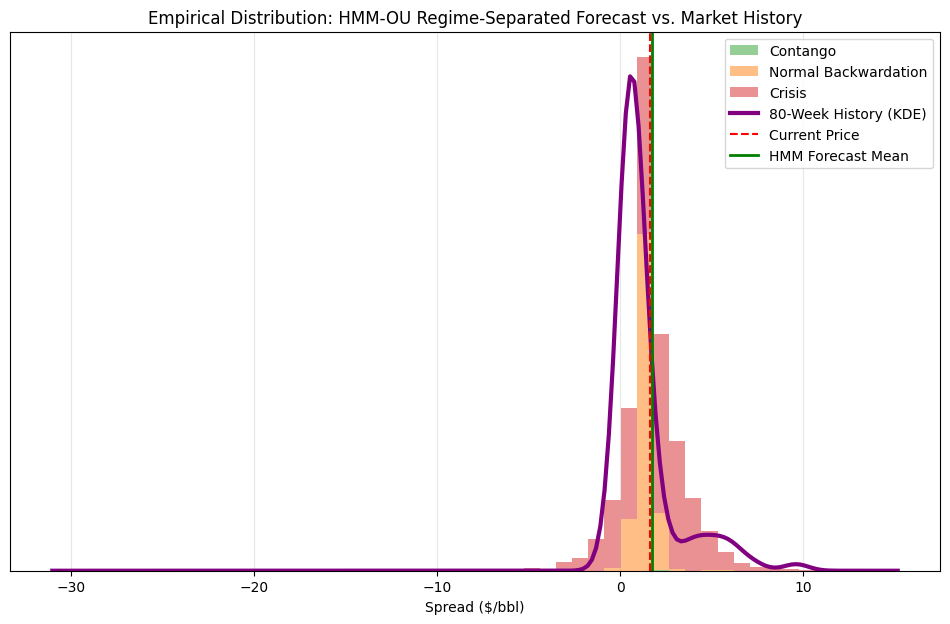

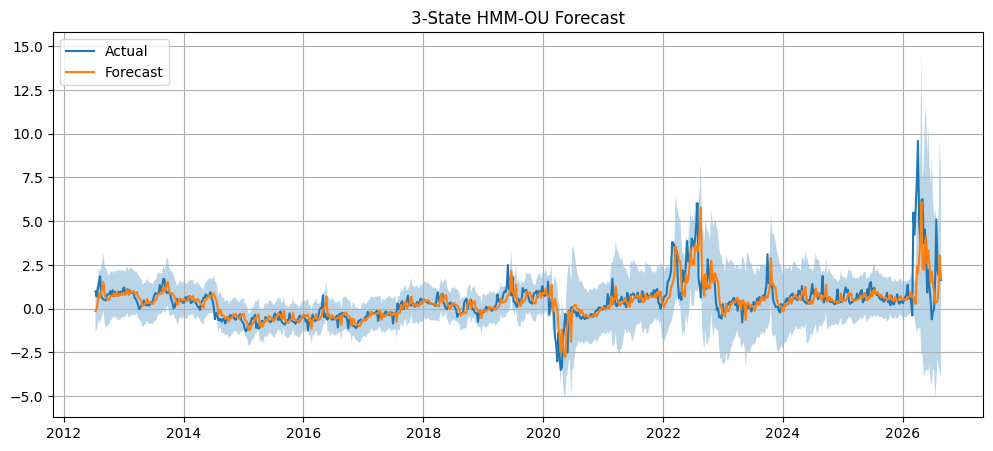

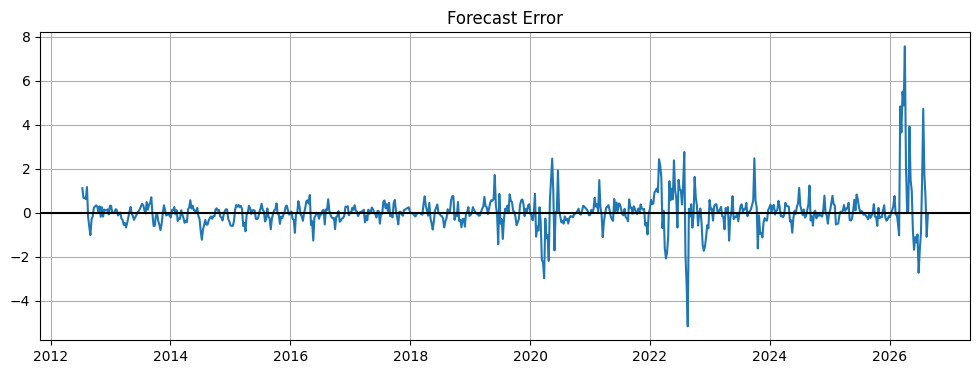

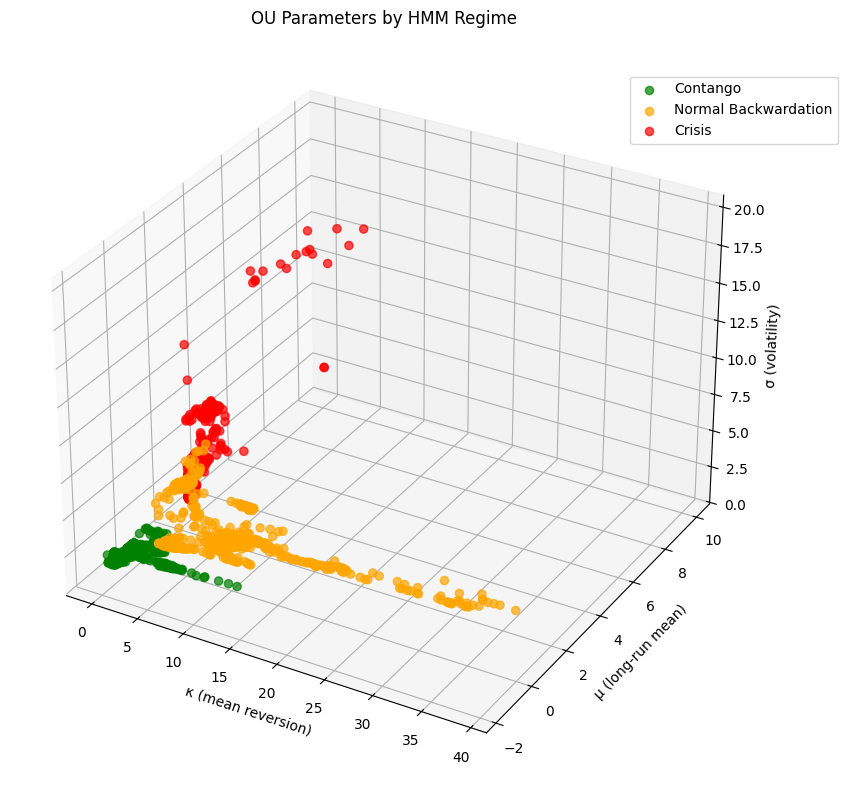

Refits: 737
Regimes: 3
Total points: 2211


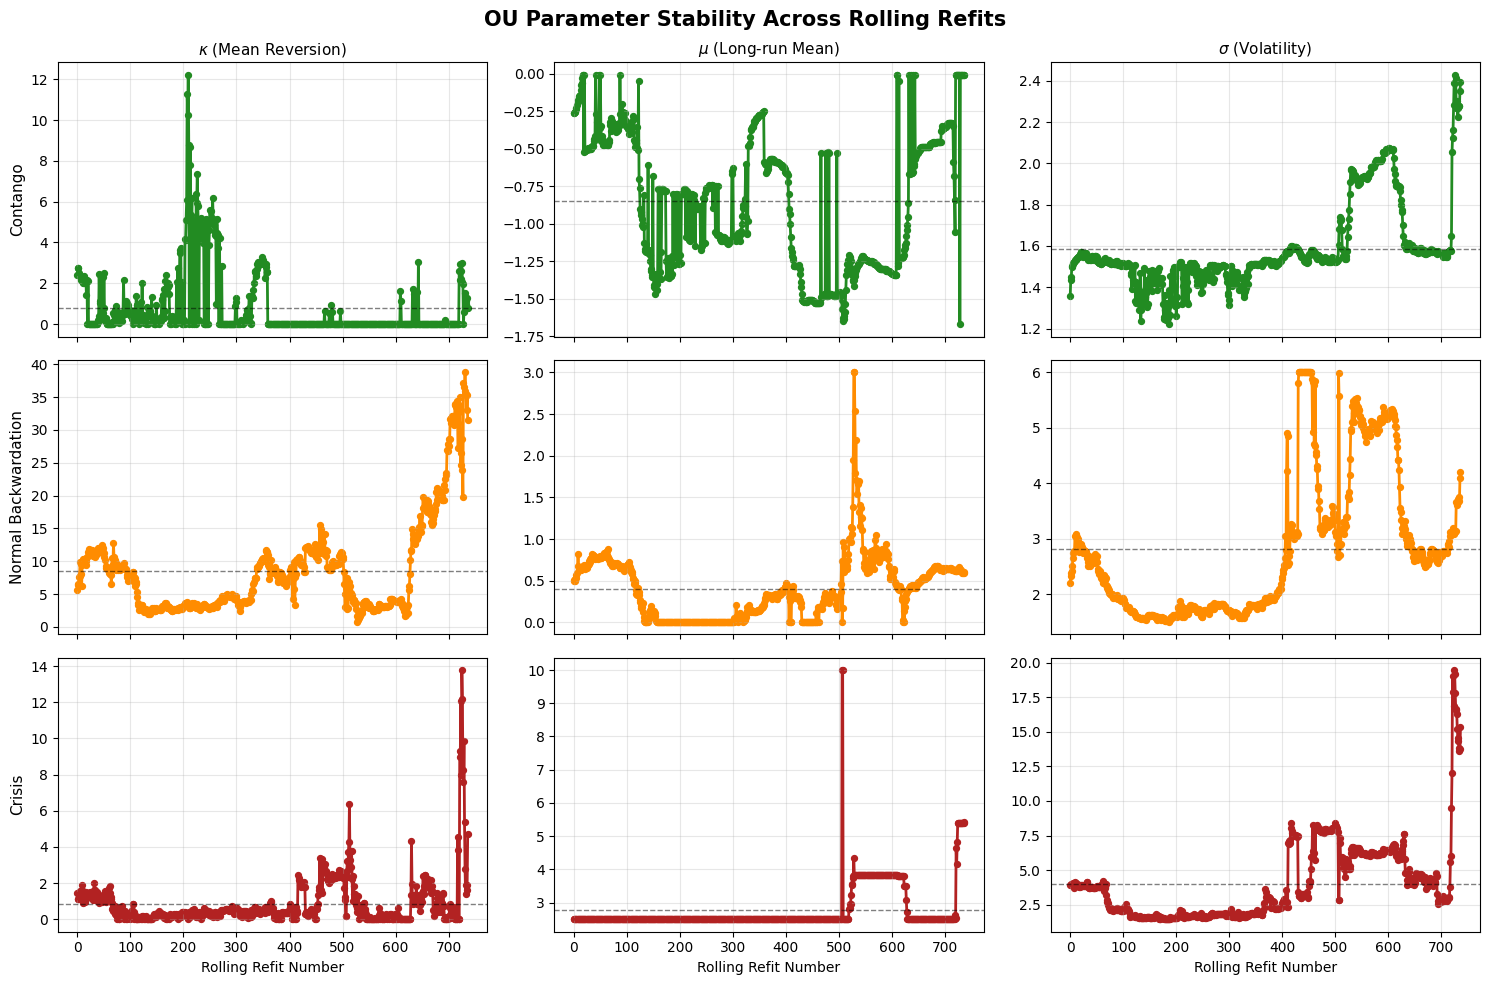

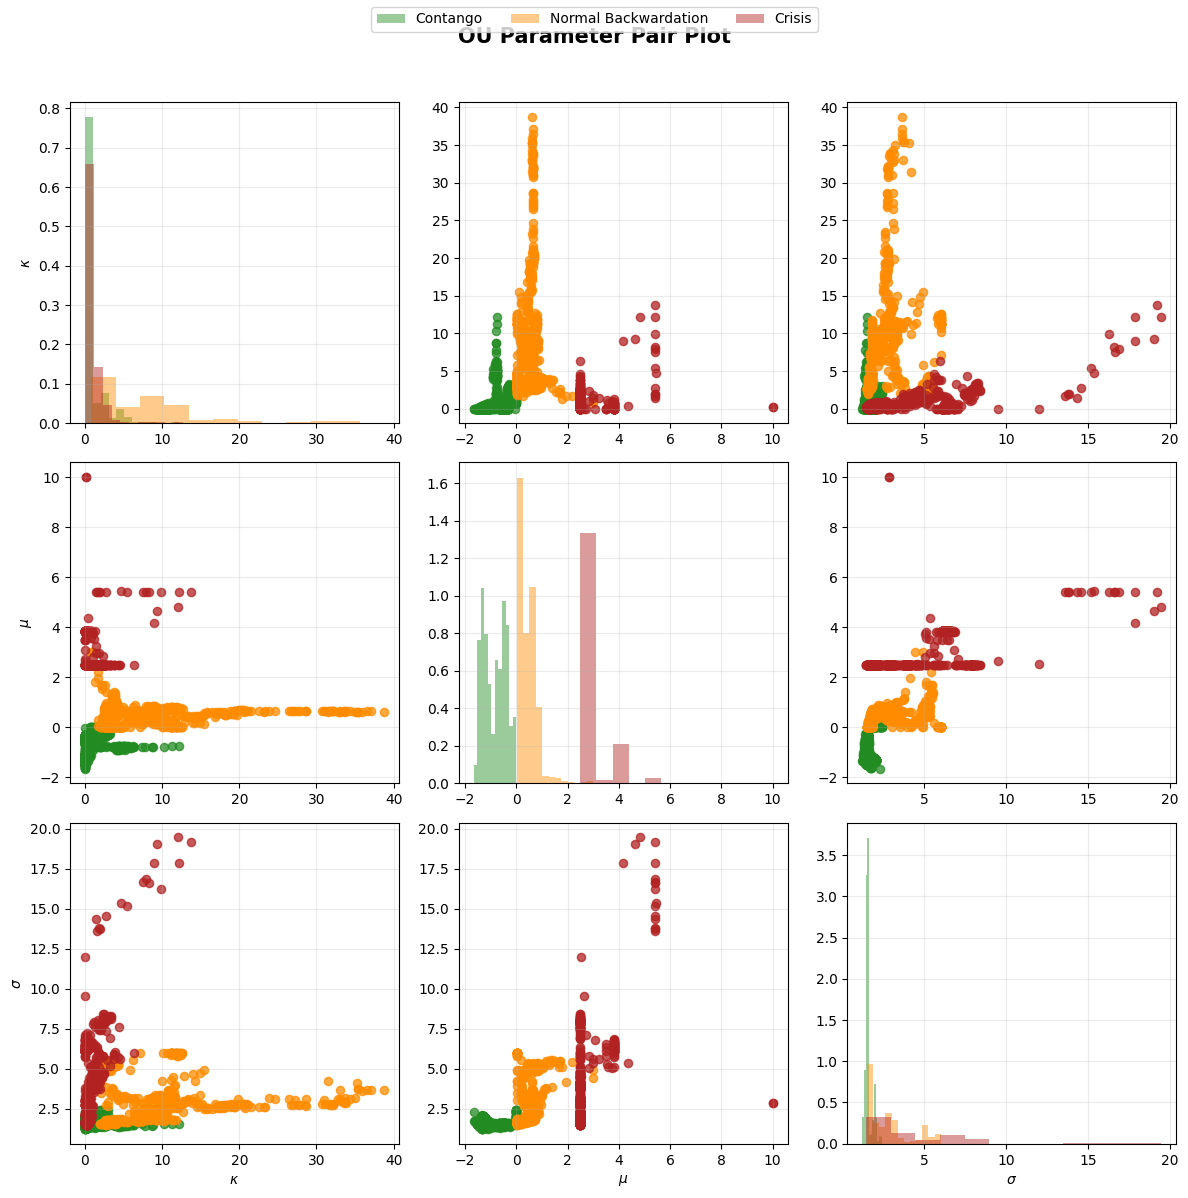

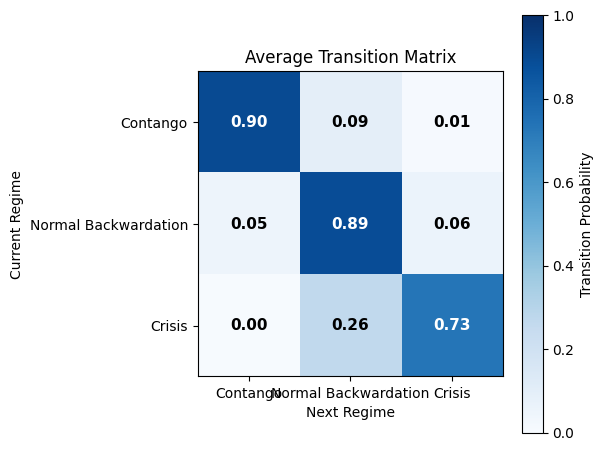

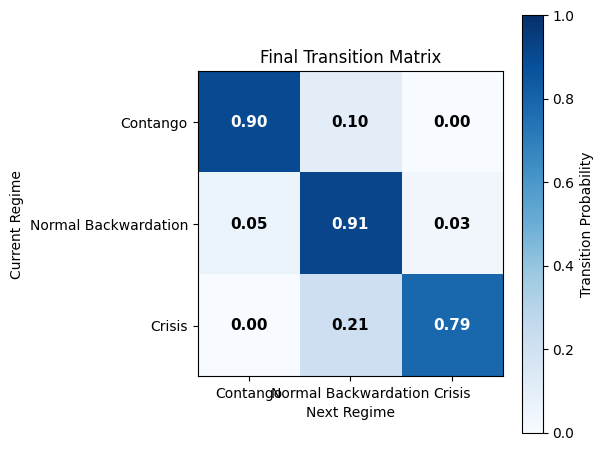

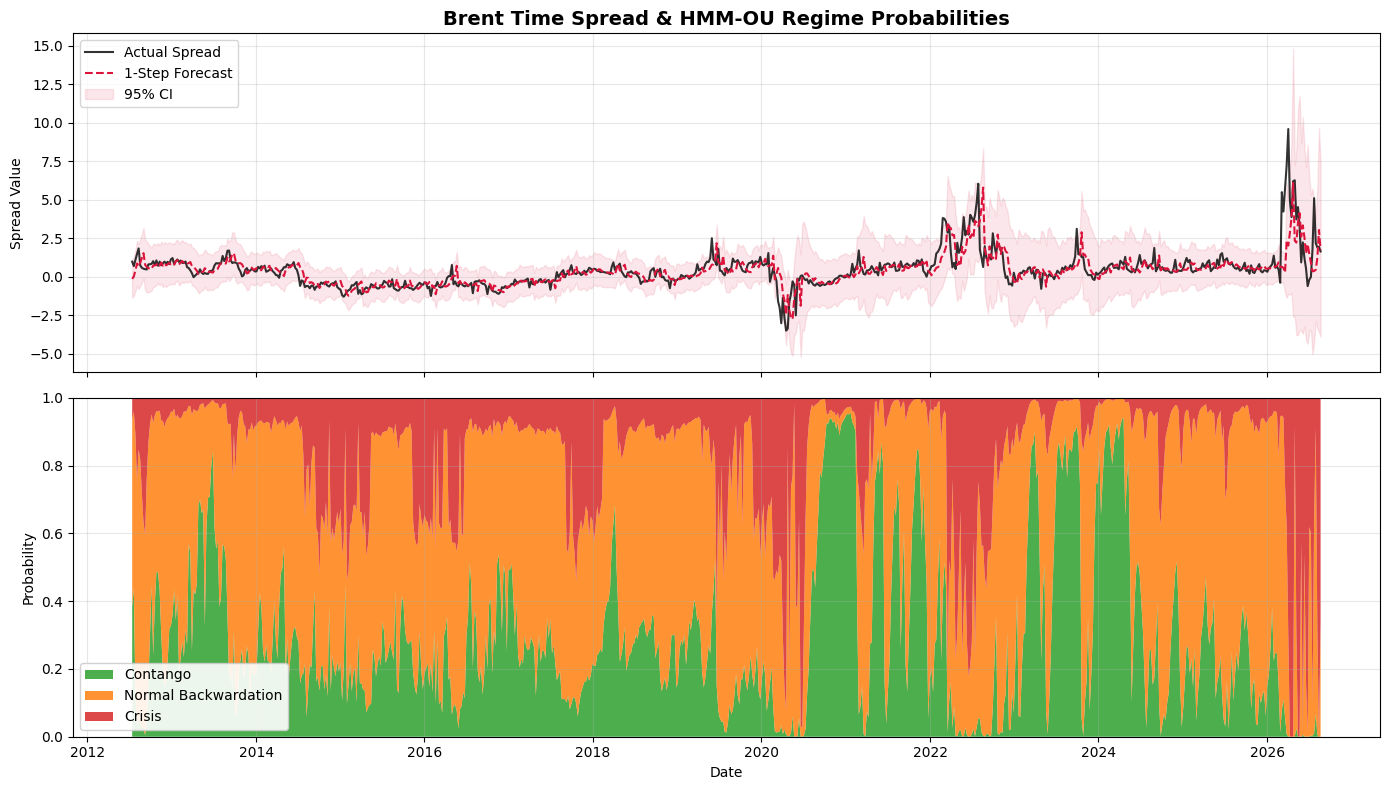

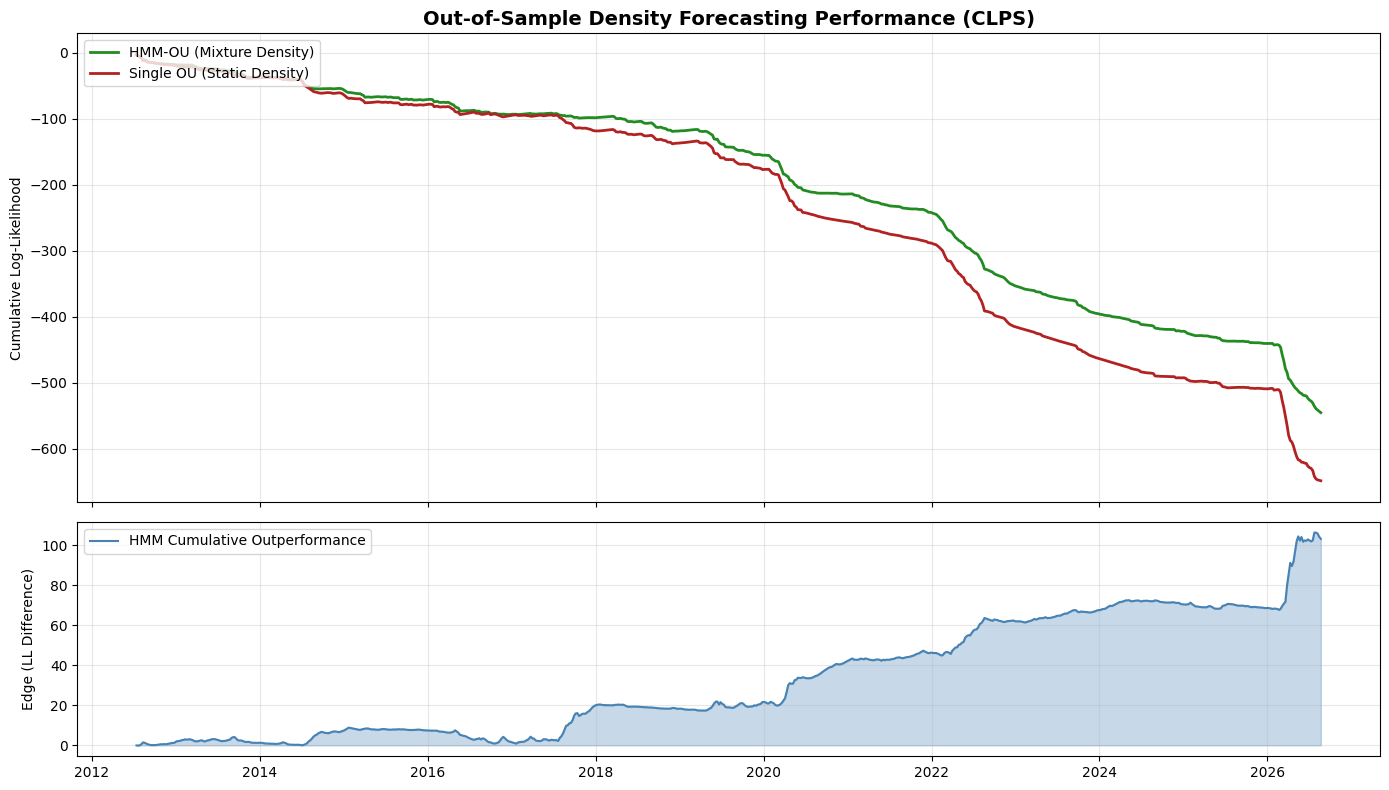


===== OUT-OF-SAMPLE DENSITY SCORES =====
HMM-OU Total Log-Likelihood   : -545.51
Single OU Total Log-Likelihood: -648.73
Total HMM Edge (Information)  : +103.22


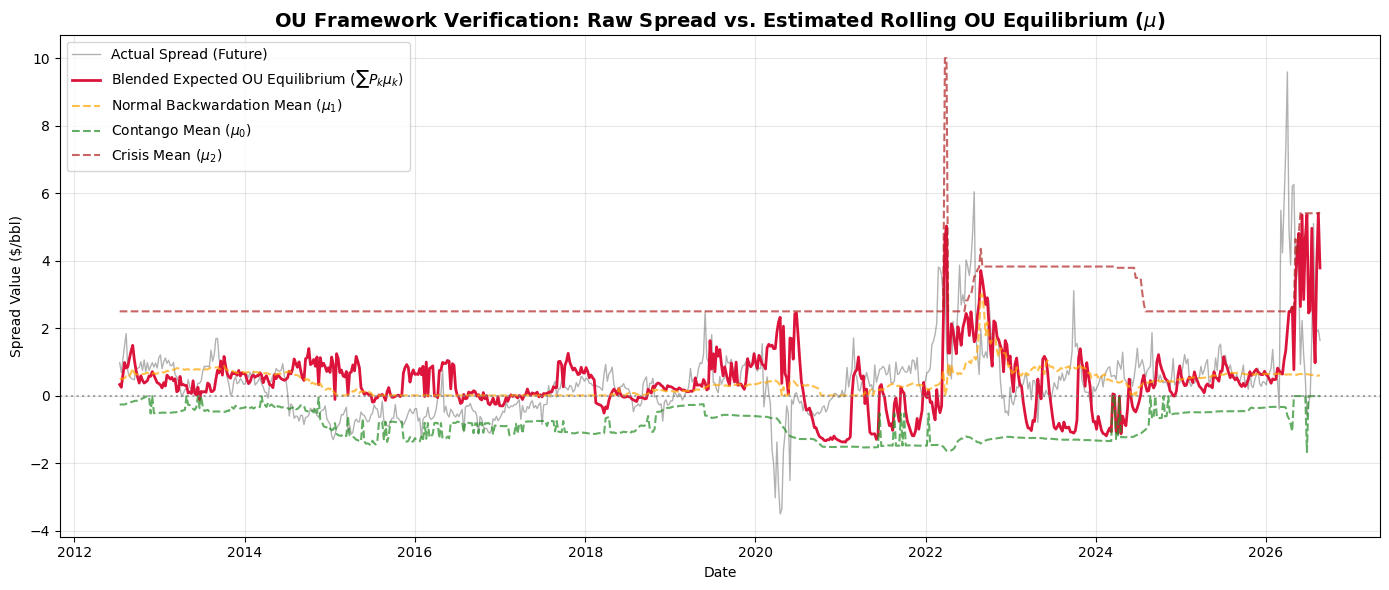

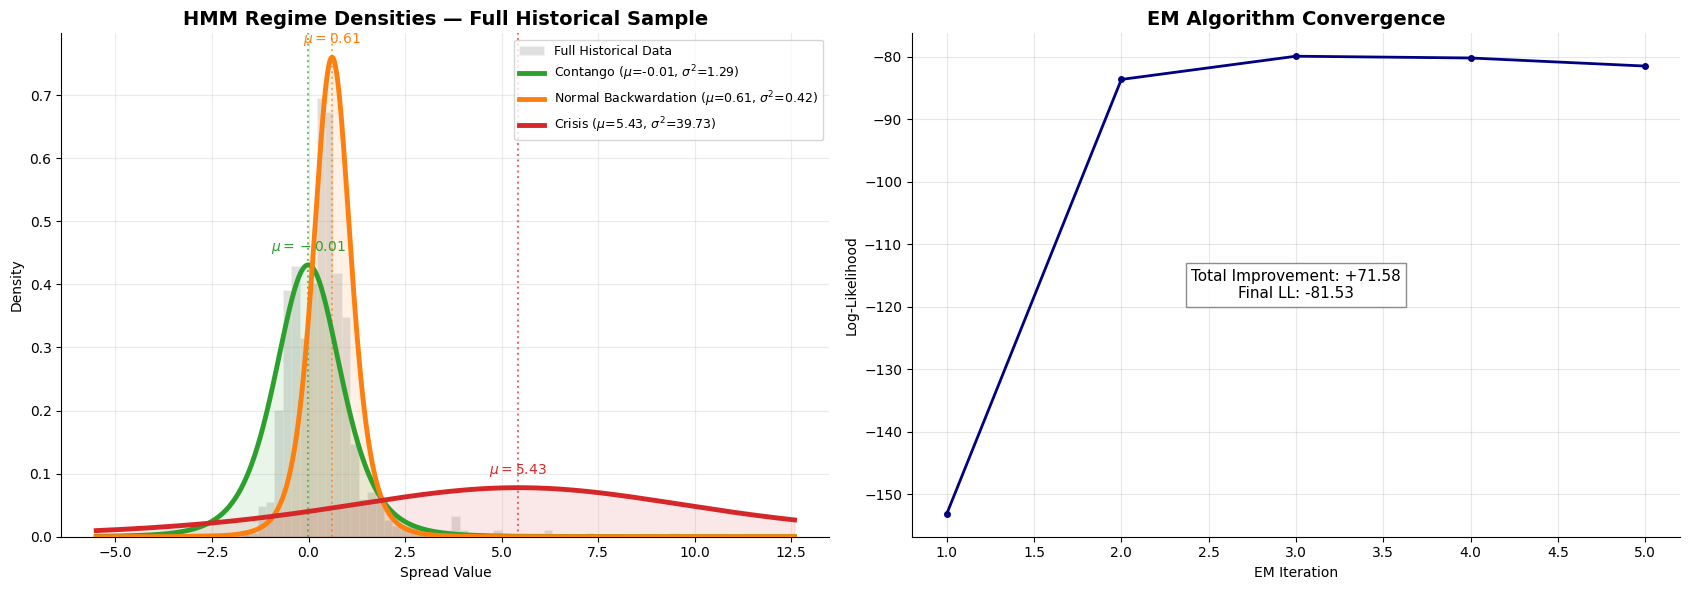

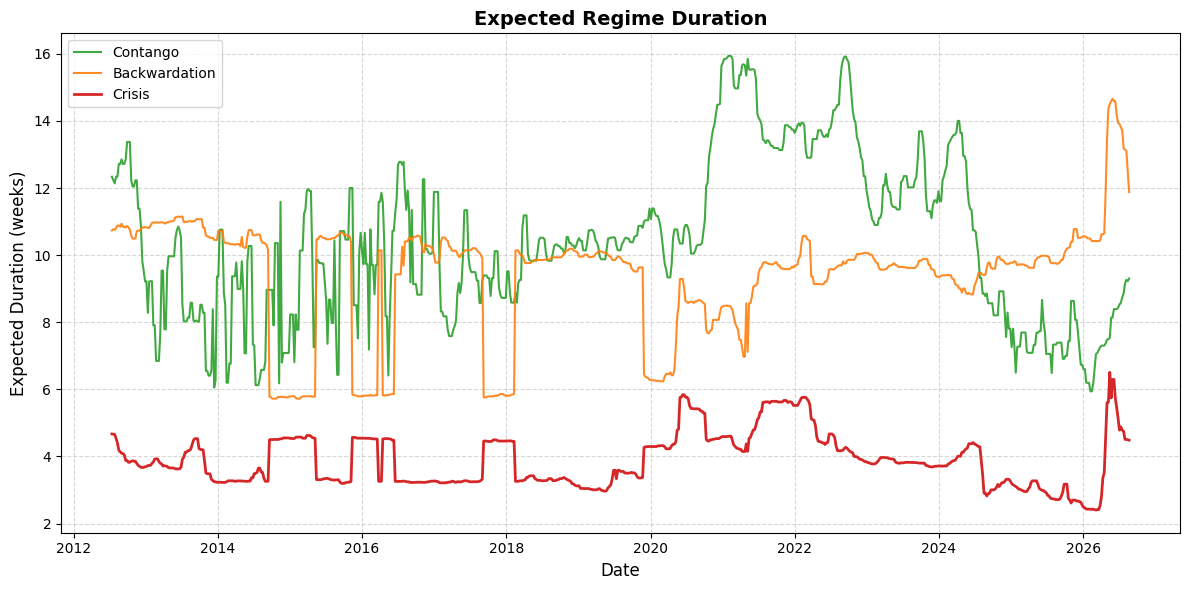

In [34]:
#plots

#simulations
plot_hmm_empirical_diagnostics(res_df=res_df,df_weekly=df_weekly,LOOKBACK=lookback,params=final_params)
#error plot
plot_results(res_df)
#parameter plots
plot_ou_parameter_3d(param_history)

plot_parameter_history_grid(param_history)
plot_parameter_pairplot(param_history)
#transition matrix
plot_transition_matrix_heatmap(P_history,average=True)
plot_transition_matrix_heatmap(P_history,average=False)
#forecast plots
plot_regime_probabilities(res_df)
plot_density_edge(res_df)
plot_estimated_ou_mean(res_df)
plot_density_and_likelihood5(params=final_params,ll_history=final_ll,full_data=df_weekly["spread"].dropna().values,regime_names=REGIME_NAMES)
plot_rolling_durations_smoothed(res_df, P_history, smooth_window=5)


## Second Bullet Header<a class="anchor" id="fourth-bullet"></a>

## Second Bullet Header<a class="anchor" id="fifth-bullet"></a>

## Second Bullet Header<a class="anchor" id="sixth-bullet"></a>

## Second Bullet Header<a class="anchor" id="seventh-bullet"></a>

## Second Bullet Header<a class="anchor" id="eighth-bullet"></a>

## Second Bullet Header<a class="anchor" id="nineth-bullet"></a>

## Second Bullet Header<a class="anchor" id="tenth-bullet"></a>

## Second Bullet Header<a class="anchor" id="eleven-bullet"></a>